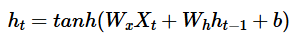

In [ ]:
# 의사 코드

# 초기 은닉 상태를 0으로 초기화
hidden_state_t = 0

# 각 시점마다의 입력을 받는다.
for input_t in input_length:
    # 각 시점에 대해서 입력과 은닉 상태를 갖고 연산
    output_t = tanh(input_t, hidden_state_t)
    # 계산 결과는 현재 시점의 은닉 상태가 됨
    hidden_state_t = output_t

# t 시점의 은닉 상태를 hidden_state_t라는 변수로 선언
# 입력 데이터의 길이를 input_length
# 이 경우 입력 데이터의 길이는 곧 총 시점의 수(timesteps)가 됨
# t 시점의 입력값을 input_t로 선언
# 각 메모리 셀은 각 시점마다 input_t와 hidden_state_t(이전 상태의 은닉 상태)를
# 입력으로 활성화 함수인 하이퍼볼릭탄젠트 함수를 통해 현 시점의 hidden_state_t를 계산

In [4]:
import numpy as np

rng = np.random.default_rng(42)

In [6]:
# 2D 텐서(timesteps, input_size) 크기를 입력으로 받는다고 가정
# 단, Pytorch에서는 3D 텐서(batch size, timesteps, input_size)를 입력으로 받음

timesteps = 10 # 시점의 수(= 문장의 길이)
input_size = 4 # 입력의 차원(= 단어 벡터의 차원)
hidden_size = 8 # 은닉 상태의 크기. 메모리 셀의 용량

inputs = rng.random((timesteps, input_size))

hidden_state_t = np.zeros((hidden_size, )) # 초기 은닉 상태는 0(벡터)로 초기화
print(hidden_state_t)

[0. 0. 0. 0. 0. 0. 0. 0.]


In [8]:
# 가중치, 편향 정의
# Wx: (은닉 상태의 크기 x 입력의 차원)
# Wh: (은닉 상태의 크기 x 은닉 상태의 크기)
# b: (은닉 상태의 크기, )
Wx = rng.random((hidden_size, input_size)) # (8, 4) 크기의 2D 텐서 입력 가중치
Wh = rng.random((hidden_size, hidden_size)) # (8, 8) 크기의 2D 텐서 은닉 가중치
b = rng.random((hidden_size,)) # (8, ) 크기의 1D 텐서 생성

print(np.shape(Wx))
print(np.shape(Wh))
print(np.shape(b))

(8, 4)
(8, 8)
(8,)


In [11]:
total_hidden_states = []

# 메모리 셀 동작
for input_t in inputs:
    output_t = np.tanh(np.dot(Wx, input_t) + np.dot(Wh, hidden_state_t) + b)
    total_hidden_states.append(list(output_t)) # 각 시점의 은닉 상태 값 계속해서 축적
    print(np.shape(total_hidden_states))
    hidden_state_t = output_t

# 출력 시 값 정리
total_hidden_states = np.stack(total_hidden_states, axis = 0)
print(total_hidden_states)

(1, 8)
(2, 8)
(3, 8)
(4, 8)
(5, 8)
(6, 8)
(7, 8)
(8, 8)
(9, 8)
(10, 8)
[[0.96115412 0.98608307 0.81654581 0.97565021 0.86557824 0.99163062
  0.95411091 0.83185776]
 [0.99999854 0.99998734 0.9997362  0.9999693  0.99997901 0.99999023
  0.99992177 0.99998387]
 [0.99999909 0.9999897  0.99971638 0.99994941 0.99996752 0.9999909
  0.99984991 0.99997516]
 [0.9999991  0.99997997 0.99959044 0.99993891 0.99998502 0.9999893
  0.99989512 0.99999012]
 [0.99999925 0.99999425 0.99947998 0.99994631 0.99995015 0.9999943
  0.99975146 0.99996361]
 [0.99999963 0.99999765 0.99975718 0.99998226 0.99997427 0.9999981
  0.99991176 0.99998227]
 [0.99999868 0.99997556 0.9989932  0.99983383 0.99995389 0.999981
  0.99962016 0.99996986]
 [0.99999941 0.999995   0.99981    0.99997998 0.99998227 0.99999625
  0.99992689 0.99998601]
 [0.99999841 0.99997234 0.999227   0.99986469 0.99996362 0.99997833
  0.99968892 0.99997304]
 [0.99999871 0.99997933 0.99959815 0.99991051 0.99996619 0.99998283
  0.99979756 0.99997457]]


In [12]:
import torch
import torch.nn as nn

In [13]:
# nn.RNN 사용
input_size = 5
hidden_size = 8

In [14]:
# 입력 텐서 정의
# (배치 크기 x 시점의 수 x 매 시점마다 들어가는 입력)
# (batch size, time steps, input size)
inputs = torch.Tensor(1, 10, 5)
# => 배치 크기는 1, 10번의 시점 동안 5차원의 입력 벡터가 들어가도록 텐서를 정의

In [15]:
# batch_first=True: 입력 텐서의 첫 번째 차원이 배치 크기임을 알려줌
cell = nn.RNN(input_size, hidden_size, batch_first=True)

In [16]:
# RNN 셀은 두 개의 입력을 return
# 첫 번째 return 값: 모든 시점(time steps)의 은닉 상태들
# 두 번째 return 값: 마지막 시점의 은닉 상태
outputs, _status = cell(inputs)

In [17]:
print(outputs.shape)

torch.Size([1, 10, 8])


In [18]:
print(_status.shape)

torch.Size([1, 1, 8])


In [20]:
# 깊은 순환 신경망(Deep RNN)
inputs = torch.Tensor(1, 10, 5)

# num_layers를 사용하여 층을 쌓음
cell = nn.RNN(input_size=5, hidden_size=8, num_layers=2, batch_first=True)
outputs, _status = cell(inputs)
print(outputs.shape)
print(_status.shape) # (층의 개수, 배치 크기, 은닉 상태의 크기)

torch.Size([1, 10, 8])
torch.Size([2, 1, 8])


In [21]:
# 양방향 순환 신경망(Bidirectional RNN)
inputs = torch.Tensor(1, 10, 5)

cell = nn.RNN(input_size=5, hidden_size=8, num_layers=2, batch_first=True,
              bidirectional=True)
outputs, _status = cell(inputs)
print(outputs.shape)
print(_status.shape)

torch.Size([1, 10, 16])
torch.Size([4, 1, 8])
